In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error


In [9]:
df_raw = pd.read_csv("../../data/raw_2020_2024.csv", 
                     index_col='datetime_utc', 
                     parse_dates=True)

print('df_raw :')
display(df_raw.head())
print('Dimensions df_raw :', df_raw.shape)
df_raw.info()


/tmp/ipykernel_9424/3260763651.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../data/raw_2020_2024.csv",


df_raw :


,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),CRU_azimuth,...,SVT_Nebulosite,SVT_Humidite,BRA_Temperature,BRA_Vitesse_Vent,BRA_Nebulosite,BRA_Humidite,EYG_Temperature,EYG_Vitesse_Vent,EYG_Nebulosite,EYG_Humidite
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,PACA,Données définitives,6123.0,0.0,3332.0,-,-,0.0,0.0,335.596867,...,29.440,57.600,3.230,1.620,5.700,86.880,2.720,1.220,51.750,100.000
2019-12-31 23:30:00+00:00,PACA,Données définitives,5907.0,0.0,2837.0,-,-,0.0,0.0,353.817769,...,24.785,56.165,3.345,1.565,4.635,84.455,2.760,1.405,54.215,98.790
2020-01-01 00:00:00+00:00,PACA,Données définitives,5724.0,0.0,2668.0,-,-,0.0,0.0,12.883689,...,20.130,54.730,3.460,1.510,3.570,82.030,2.800,1.590,56.680,97.580
2020-01-01 00:30:00+00:00,PACA,Données définitives,5749.0,0.0,2754.0,-,-,0.0,0.0,30.261125,...,10.340,54.250,3.650,1.435,3.040,79.380,2.675,1.635,33.325,96.065
2020-01-01 01:00:00+00:00,PACA,Données définitives,5700.0,0.0,2886.0,-,-,0.0,0.0,44.631373,...,0.550,53.770,3.840,1.360,2.510,76.730,2.550,1.680,9.970,94.550


Dimensions df_raw : (87696, 89)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 87696 entries, 2019-12-31 23:00:00+00:00 to 2024-12-31 22:30:00+00:00
Data columns (total 89 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Périmètre            87696 non-null  object 
 1   Nature               87696 non-null  object 
 2   Consommation         87696 non-null  float64
 3   Solaire              87696 non-null  float64
 4   Ech. physiques       87696 non-null  float64
 5   Stockage batterie    87696 non-null  object 
 6   Déstockage batterie  87696 non-null  object 
 7   TCO Solaire (%)      87696 non-null  float64
 8   TCH Solaire (%)      87696 non-null  float64
 9   CRU_azimuth          87696 non-null  float64
 10  CRU_altitude         87696 non-null  float64
 11  SEL_azimuth          87696 non-null  float64
 12  SEL_altitude         87696 non-null  float64
 13  SVT_azimuth          87696 non-null  float64
 14  SVT_alt

In [8]:
df_tuned = pd.read_csv("../../data/dataset_pv_variability_paca_2020_2024.csv", 
                       index_col='Date', 
                       parse_dates=True)

print('\ndf_tuned :')
display(df_tuned.head())
print('Dimensions df_tuned :', df_tuned.shape)
df_tuned.info()



df_tuned :


,Unnamed: 0,Consommation,Solaire,Ech._physiques,tco,tch,solar_azimuth_region,solar_altitude_region,temperature_region,ghi_region,...,sin_hour,cos_hour,sin_day,cos_day,sin_dow,cos_dow,day_of_year,sin_doy,cos_doy,season
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,7,5433.0,0.0,3922.0,0.0,0.0,73.153022,-49.612365,3.51620,0.0,...,0.608761,0.793353,0.0,1.0,0.974928,-0.222521,1,0.017213,0.999852,winter
2020-01-01 03:00:00+00:00,8,5332.0,0.0,3878.0,0.0,0.0,79.705519,-44.351772,3.36130,0.0,...,0.707107,0.707107,0.0,1.0,0.974928,-0.222521,1,0.017213,0.999852,winter
2020-01-01 03:30:00+00:00,9,5219.0,0.0,3751.0,0.0,0.0,85.516174,-38.985473,3.26355,0.0,...,0.793353,0.608761,0.0,1.0,0.974928,-0.222521,1,0.017213,0.999852,winter
2020-01-01 04:00:00+00:00,10,5157.0,0.0,3631.0,0.0,0.0,90.833727,-33.577090,3.16580,0.0,...,0.866025,0.500000,0.0,1.0,0.974928,-0.222521,1,0.017213,0.999852,winter
2020-01-01 04:30:00+00:00,11,5161.0,0.0,3636.0,0.0,0.0,95.836426,-28.175070,3.22595,0.0,...,0.923880,0.382683,0.0,1.0,0.974928,-0.222521,1,0.017213,0.999852,winter


Dimensions df_tuned : (87689, 51)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 87689 entries, 2020-01-01 02:30:00+00:00 to 2024-12-31 22:30:00+00:00
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             87689 non-null  int64  
 1   Consommation           87689 non-null  float64
 2   Solaire                87689 non-null  float64
 3   Ech._physiques         87689 non-null  float64
 4   tco                    87689 non-null  float64
 5   tch                    87689 non-null  float64
 6   solar_azimuth_region   87689 non-null  float64
 7   solar_altitude_region  87689 non-null  float64
 8   temperature_region     87689 non-null  float64
 9   ghi_region             87689 non-null  float64
 10  bhi_region             87689 non-null  float64
 11  dhi_region             87689 non-null  float64
 12  dni_region             87689 non-null  float64
 13  wind_speed_region      87

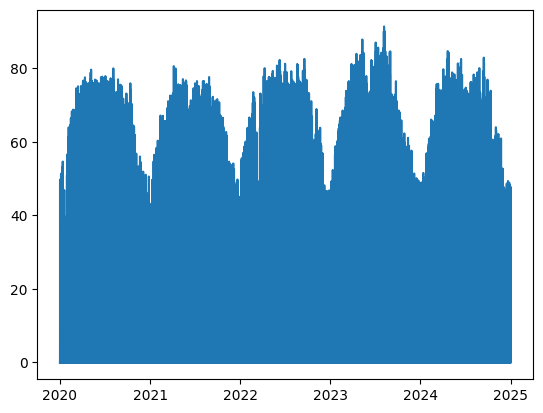

In [14]:

plt.plot(df_raw.index, df_raw["TCH Solaire (%)"])
plt.show()
#model_lr_raw = LinearRegression()
